In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import joblib
import json

In [3]:
# ==================== 1. 数据准备 ====================
df = pd.read_csv('parameter.csv')


# ==================== 2. 特征工程（修正版）====================

# 2.1 条件参数激活：根据 type 消除物理无效参数
# type=1(水平): hori_rot 有效, ver_rot 无效
# type=2(垂直): ver_rot 有效, hori_rot 无效  
# type=3(混合): 两者均有效
df['hori_rot_eff'] = df['hori_rot'] * df['type'].isin([1, 3]).astype(int)
df['ver_rot_eff'] = df['ver_rot'] * df['type'].isin([2, 3]).astype(int)

# 关键：删除原始旋转角度列，避免模型学到条件无关的虚假相关性
df = df.drop(columns=['hori_rot', 'ver_rot'])

# 2.2 U值映射（原代码保持不变）
u_value_map = {1: 3.54, 2: 1.84, 3: 2.59, 4: 1.71} 
df['glazing_u_value'] = df['win'].map(u_value_map)

# 2.3 交互特征（改用 _eff 版本，确保无效路径被切断）
df['thermal_load_index'] = (df['wwr'] / 100) * df['glazing_u_value']
df['wwr_ver_rot'] = df['wwr'] * df['ver_rot_eff']   # ← 改用 ver_rot_eff
df['wwr_int'] = df['wwr'] * df['int']
df['shade_balance'] = df['hor_depth'] / (df['wwr'])

# 如有其他涉及 hori_rot/ver_rot 的交互特征，同理改用 _eff 版本

# ==================== 3. 独热编码（后续流程完全不变）====================
categorical_cols = ['type', 'mat', 'win']
df_encoded = pd.get_dummies(df, columns=categorical_cols)
X = df_encoded.drop(columns=['Energy', 'sDGP'])
y_energy = df_encoded['Energy']


# ==================== 4. 划分测试集 ====================
X_train, X_test, y_train_e, y_test_e = train_test_split(
    X, y_energy, test_size=0.2, random_state=42
)

In [3]:
# 立即运行这段代码检查
print(df['win'].unique())
print(df['glazing_u_value'].isna().sum(), "/", len(df))

[2 3 4 1]
0 / 1024


In [4]:
# ==================== 5. 训练最终模型（使用最优参数）====================
params_energy = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.06,
    'max_depth': 3,
    'n_estimators': 900,    # 收敛测试找到的最优值
    'reg_alpha': 1.0,
    'reg_lambda': 5.0,
    'subsample': 0.6,
    'random_state': 311,
    'min_child_weight': 3,  # 叶子节点最小样本权重和（约等于min_samples_leaf）
    'gamma': 0.2,           # 节点分裂所需最小损失减少
}

print("\n正在训练能耗模型...")
model_e = xgb.XGBRegressor(**params_energy)
model_e.fit(X_train, y_train_e)


正在训练能耗模型...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.2, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.06, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=900,
             n_jobs=None, num_parallel_tree=None, ...)

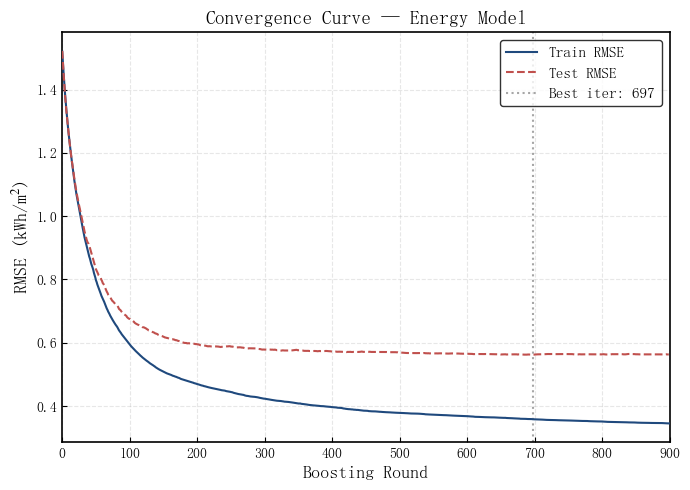


【收敛性诊断】
总迭代轮次: 900 | 最优测试轮次: 697
最优测试 RMSE: 0.5625
最终测试 RMSE: 0.5632
✓ 模型已收敛，测试损失未出现明显反弹


In [6]:
# ==================== 5.5 收敛性验证：迭代学习曲线 ====================
# 使用相同参数独立训练监控模型，不影响最终 model_e
eval_params_e = params_energy.copy()
eval_params_e['eval_metric'] = 'rmse'  # ← 移至初始化，兼容所有 XGBoost 版本

eval_model_e = xgb.XGBRegressor(**eval_params_e)
eval_model_e.fit(
    X_train, y_train_e,
    eval_set=[(X_train, y_train_e), (X_test, y_test_e)],
    verbose=False
)

results_e = eval_model_e.evals_result()
epochs_e = len(results_e['validation_0']['rmse'])
x_axis_e = range(0, epochs_e)
best_iter_e = int(np.argmin(results_e['validation_1']['rmse']))

# SCI 标准图（后续绘图代码完全不变）
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['SimSun', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.linewidth'] = 1.2

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x_axis_e, results_e['validation_0']['rmse'], '-', color='#1f497d', 
        linewidth=1.5, label='Train RMSE', zorder=3)
ax.plot(x_axis_e, results_e['validation_1']['rmse'], '--', color='#c0504d', 
        linewidth=1.5, label='Test RMSE', zorder=3)
ax.axvline(x=best_iter_e, color='gray', linestyle=':', alpha=0.7, 
           label=f'Best iter: {best_iter_e}', zorder=2)
ax.set_xlabel('Boosting Round', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE (kWh/m$^2$)', fontsize=13, fontweight='bold')
ax.set_title('Convergence Curve — Energy Model', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', frameon=True, edgecolor='black', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_xlim(0, epochs_e)

plt.tight_layout()
plt.savefig('s_Energy_Convergence.png', dpi=600, bbox_inches='tight')
plt.show()

print(f"\n【收敛性诊断】")
print(f"总迭代轮次: {epochs_e} | 最优测试轮次: {best_iter_e}")
print(f"最优测试 RMSE: {results_e['validation_1']['rmse'][best_iter_e]:.4f}")
print(f"最终测试 RMSE: {results_e['validation_1']['rmse'][-1]:.4f}")
if results_e['validation_1']['rmse'][-1] > results_e['validation_1']['rmse'][best_iter_e] * 1.02:
    print("⚠️ 最终迭代较最优迭代测试损失上升 >2%，建议启用 early_stopping_rounds")
else:
    print("✓ 模型已收敛，测试损失未出现明显反弹")

In [6]:
# ==================== 6. 验证评估 ====================
pred_e = model_e.predict(X_test)

r2_e = r2_score(y_test_e, pred_e)
rmse_e = np.sqrt(mean_squared_error(y_test_e, pred_e))
mae_e = mean_absolute_error(y_test_e, pred_e)

print(f"\n能耗验证结果: R²={r2_e:.3f}, RMSE={rmse_e:.3f}")


能耗验证结果: R²=0.870, RMSE=0.563


In [9]:
# ==================== 6.5 过拟合诊断：训练/测试对比 + 5-Fold CV ====================
from sklearn.model_selection import cross_validate, KFold

# 6.5.1 同参数训练集 vs 测试集量化
pred_train_e = model_e.predict(X_train)
r2_train_e = r2_score(y_train_e, pred_train_e)
rmse_train_e = np.sqrt(mean_squared_error(y_train_e, pred_train_e))
mae_train_e = mean_absolute_error(y_train_e, pred_train_e)

# 过拟合率定义：R² 用 (Train-Test)/Train；RMSE 用 (Test-Train)/Test（正值即过拟合）
overfit_r2_e = (r2_train_e - r2_e) / r2_train_e * 100 if r2_train_e > 0 else 0
overfit_rmse_e = (rmse_e - rmse_train_e) / rmse_e * 100 if rmse_e > 0 else 0

print(f"\n{'='*60}")
print("【过拟合诊断】训练集 vs 测试集性能对比")
print(f"{'='*60}")
print(f"{'Metric':<<12} {'Train':>12} {'Test':>12} {'Gap':>12} {'Overfit%':>12}")
print(f"{'-'*60}")
print(f"{'R²':<<12} {r2_train_e:>12.4f} {r2_e:>12.4f} {r2_train_e-r2_e:>12.4f} {overfit_r2_e:>11.2f}%")
print(f"{'RMSE':<<12} {rmse_train_e:>12.4f} {rmse_e:>12.4f} {rmse_e-rmse_train_e:>12.4f} {overfit_rmse_e:>11.2f}%")
print(f"{'MAE':<<12} {mae_train_e:>12.4f} {mae_e:>12.4f} {mae_e-mae_train_e:>12.4f} {'—':>12}")

if overfit_r2_e > 5:
    print("⚠️  R² 过拟合率 > 5%，建议增大 reg_lambda / 降低 max_depth")
elif overfit_r2_e < -1:
    print("ℹ️  测试集表现略优于训练集（数据划分波动或样本量较小）")
else:
    print("✓  泛化差距在可接受范围（<<5%）")

# 6.5.2 5-Fold 交叉验证稳定性
cv_model_e = xgb.XGBRegressor(**params_energy)
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'r2': 'r2', 'rmse': 'neg_root_mean_squared_error', 'mae': 'neg_mean_absolute_error'}
cv_res_e = cross_validate(cv_model_e, X, y_energy, cv=cv_strategy, scoring=scoring, 
                          return_train_score=True, n_jobs=-1)

r2_train_cv_e = cv_res_e['train_r2']
r2_test_cv_e = cv_res_e['test_r2']
rmse_test_cv_e = -cv_res_e['test_rmse']

print(f"\n{'='*60}")
print("【交叉验证稳定性】5-Fold CV")
print(f"{'='*60}")
print(f"{'Fold':<<6} {'Train R²':>10} {'Test R²':>10} {'Test RMSE':>12}")
print(f"{'-'*60}")
for i in range(5):
    print(f"{i+1:<6} {r2_train_cv_e[i]:>10.4f} {r2_test_cv_e[i]:>10.4f} {rmse_test_cv_e[i]:>12.4f}")
print(f"{'-'*60}")
print(f"{'Mean':<<6} {r2_train_cv_e.mean():>10.4f} {r2_test_cv_e.mean():>10.4f} {rmse_test_cv_e.mean():>12.4f}")
print(f"{'Std':<<6} {r2_train_cv_e.std():>10.4f} {r2_test_cv_e.std():>10.4f} {rmse_test_cv_e.std():>12.4f}")

cv_gap_e = r2_train_cv_e.mean() - r2_test_cv_e.mean()
print(f"\nCV 平均泛化差距 (R²): {cv_gap_e:.4f}")
if cv_gap_e > 0.05:
    print("⚠️  CV 泛化差距 > 0.05，模型稳定性不足")
elif r2_test_cv_e.std() > 0.02:
    print("⚠️  CV 测试 R² 标准差 > 0.02，不同折表现波动较大")
else:
    print("✓  CV 结果稳定，泛化性能可靠")


【过拟合诊断】训练集 vs 测试集性能对比
Metric<<<<<<        Train         Test          Gap     Overfit%
------------------------------------------------------------
R²<<<<<<<<<<       0.9509       0.8701       0.0808        8.50%
RMSE<<<<<<<<       0.3454       0.5632       0.2177       38.66%
MAE<<<<<<<<<       0.2620       0.4262       0.1642            —
⚠️  R² 过拟合率 > 5%，建议增大 reg_lambda / 降低 max_depth

【交叉验证稳定性】5-Fold CV
Fold<<   Train R²    Test R²    Test RMSE
------------------------------------------------------------
1          0.9509     0.8580       0.5890
2          0.9508     0.8674       0.5913
3          0.9501     0.8387       0.6637
4          0.9519     0.8473       0.5845
5          0.9524     0.8596       0.5454
------------------------------------------------------------
Mean<<     0.9512     0.8542       0.5948
Std<<<     0.0008     0.0101       0.0383

CV 平均泛化差距 (R²): 0.0970
⚠️  CV 泛化差距 > 0.05，模型稳定性不足


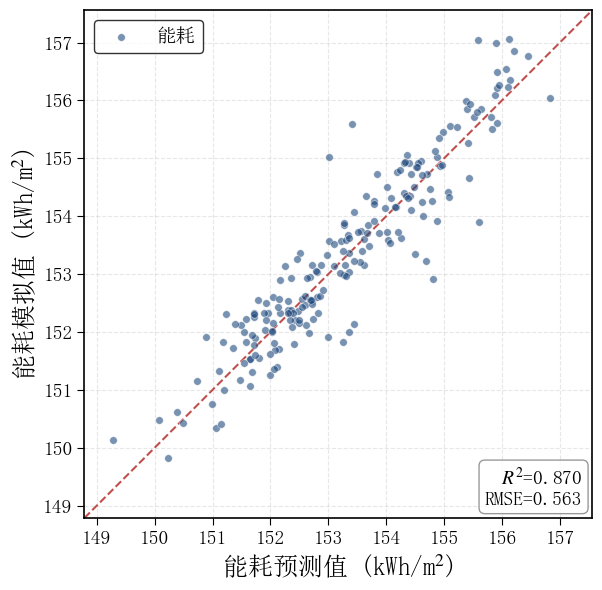

In [7]:
# ==================== 7. SCI 标准验证图 ====================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['SimSun', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['axes.linewidth'] = 1.2

fig, ax = plt.subplots(figsize=(7, 6))

color_e = '#1f497d'
line_color = '#c0504d'
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)
min_e, max_e = min(min(pred_e), min(y_test_e))-0.5, max(max(pred_e), max(y_test_e))+0.5
# ==================== 新增：强制 x/y 刻度完全同步 ====================
import numpy as np
ticks = np.arange(np.floor(min_e), np.ceil(max_e)+1, 1)  # 每 1 个单位一条
ax.set_xticks(ticks)
ax.set_yticks(ticks)
# ===================================================================

ax.scatter(pred_e, y_test_e, s=30, c=color_e, alpha=0.6, edgecolors='white', linewidth=0.5, zorder=3)
ax.plot([min_e, max_e], [min_e, max_e], '--', color=line_color, linewidth=1.5, zorder=2)
#ax.set_xlabel('Predicted energy consumption (kWh/m$^2$)', fontsize=14, fontweight='bold')
#ax.set_ylabel('Simulated energy consumption (kWh/m$^2$)', fontsize=14, fontweight='bold')
ax.set_xlabel('能耗预测值 (kWh/m$^2$)', fontsize=18, fontweight='bold')
ax.set_ylabel('能耗模拟值 (kWh/m$^2$)', fontsize=18, fontweight='bold')
#ax.set_title('Surrogate Model Validation - Energy Consumption', fontsize=15, fontweight='bold')
ax.set_xlim(min_e, max_e)
ax.set_ylim(min_e, max_e)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(['能耗'], loc='upper left', frameon=True, edgecolor='black',fontsize=14)
ax.text(0.98, 0.02, f'$R^2$={r2_e:.3f}\nRMSE={rmse_e:.3f}', transform=ax.transAxes,
        fontsize=14, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.savefig('s_XGBoost_Energy_Validation_cn_type_fixed.png', dpi=600, bbox_inches='tight')
plt.show()

In [6]:
# ==================== 8. 使用全量数据重新训练并保存 ====================
print("\n使用全量数据训练最终模型并保存...")

final_model_e = xgb.XGBRegressor(**params_energy)
final_model_e.fit(X, y_energy)

final_model_e.save_model('s_xgb_energy_final.json')
joblib.dump(final_model_e, 's_xgb_energy_final.pkl')

feature_names = X.columns.tolist()
with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)

config = {
    'energy_params': params_energy,
    'features': feature_names,
    'performance': {'energy_r2': float(r2_e), 'energy_rmse': float(rmse_e), 'energy_mae': float(mae_e)}
}
with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("✓ 模型已保存")


使用全量数据训练最终模型并保存...
✓ 模型已保存


In [7]:
# ==================== 9. 保存测试集预测结果 ====================
results_df = pd.DataFrame({
    'actual_energy': y_test_e.values if hasattr(y_test_e, 'values') else y_test_e,
    'pred_energy': pred_e,
    'error_energy': (y_test_e.values if hasattr(y_test_e, 'values') else y_test_e) - pred_e
})

X_test_reset = X_test.reset_index(drop=True)
results_full = pd.concat([X_test_reset, results_df], axis=1)

results_full.to_csv('prediction_results_type_fixed.csv', index=False)
print("✓ 预测结果已保存: prediction_results_type_fixed.csv")
print(f"  包含 {len(results_full)} 个测试样本")

✓ 预测结果已保存: prediction_results_type_fixed.csv
  包含 205 个测试样本


In [8]:
# ==================== 可选：超参数自动调优（GridSearchCV示例） ====================
# 如需自动调优，取消下面代码注释（耗时较长）
'''
print("\n正在进行超参数网格搜索（约需5-10分钟）...")

param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0.5, 1.0, 2.0]
}

# 能耗模型调优
grid_e = GridSearchCV(
    xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    param_grid, 
    cv=5,           # 5折交叉验证
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid_e.fit(X, y_energy)
print(f"最优能耗参数: {grid_e.best_params_}")
print(f"最优能耗RMSE: {np.sqrt(-grid_e.best_score_):.3f}")


SyntaxError: incomplete input (2454204880.py, line 3)